In [1]:
# 第2章｜K 線型態哪種最有用：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# K 線型態哪種最有用？

**對應影片**：第 2 章 單元 4「K 線型態哪種最有用」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| `data.talib('CDL2CROWS')` | `data.indicator('CDL2CROWS')`，一次算好所有股票 |
| 用開盤價自己計算 1、5、10、60 日後的報酬 | 用 `finlab.ml.label.return_percentage` 計算「隔天開盤買進、持有 N 天」的報酬 |
| `from finlab.plot_candles import plot_candles` | 用 matplotlib 自己畫 K 線（程式在下方） |

TA-Lib 內建 61 種 K 線型態。每一種型態在每支股票、每一天的值是：
`100` 看漲型態出現、`-100` 看跌型態出現、`0` 沒出現。
我們統計每種型態出現之後，股價平均漲跌多少。

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import talib
import finlab.ml.label as label

PATTERNS = talib.get_function_groups()['Pattern Recognition']
HOLDING_PERIODS = [1, 5, 10, 60]
MIN_AVG_VOLUME_SHARES = 100_000
MIN_EVENTS = 100

print(f'共 {len(PATTERNS)} 種型態，例如：', PATTERNS[:5])

共 61 種型態，例如： ['CDL2CROWS', 'CDL3BLACKCROWS', 'CDL3INSIDE', 'CDL3LINESTRIKE', 'CDL3OUTSIDE']


## 1. 先看一種型態：CDL2CROWS（兩隻烏鴉）

In [3]:
two_crows = data.indicator('CDL2CROWS')
two_crows.stack().value_counts()

 0      6001129
-100       2700
Name: count, dtype: int64

## 2. 找出所有型態出現的時間點

成交量太小的股票，K 線容易被少數交易影響，所以只統計「近 10 日平均成交量大於 `MIN_AVG_VOLUME_SHARES` 股」的股票。

In [4]:
volume = data.get('price:成交股數')
liquid = volume.average(10) > MIN_AVG_VOLUME_SHARES


def pattern_events(name: str) -> pd.Series:
    """回傳某型態在流動性足夠的股票上出現的所有 (日期, 股票)，值為 100 或 -100。"""
    signal = data.indicator(name)
    signal = signal.where(liquid.reindex_like(signal).eq(True), 0)
    stacked = signal.stack()
    return stacked[stacked != 0]


events = pd.concat({name: pattern_events(name) for name in PATTERNS}, names=['pattern', 'datetime', 'instrument'])
events = events.rename('signal').reset_index()
events['direction'] = events['signal'].map({100: 'bullish', -100: 'bearish'})
print(f'共 {len(events):,} 次型態訊號')
events.head()

共 6,993,140 次型態訊號


,pattern,datetime,instrument,signal,direction
0,CDL2CROWS,2007-05-10,8906,-100,bearish
1,CDL2CROWS,2007-05-16,3083,-100,bearish
2,CDL2CROWS,2007-05-23,2022,-100,bearish
3,CDL2CROWS,2007-05-23,6116,-100,bearish
4,CDL2CROWS,2007-05-24,2376,-100,bearish


## 3. 計算型態出現後的報酬

每個訊號都計算「隔天開盤買進，持有 1、5、10、60 個交易日」的報酬率。
同一天同一支股票可能同時出現好幾種型態，所以先把不重複的 (日期, 股票) 算一次報酬，再對回每個訊號。

In [5]:
event_index = pd.MultiIndex.from_frame(events[['datetime', 'instrument']].drop_duplicates())

returns = pd.DataFrame({
    f'return_{period}d': label.return_percentage(event_index, period=period, trade_at_price='open')
    for period in HOLDING_PERIODS
})
returns.index = returns.index.set_names(['datetime', 'instrument'])
events = events.join(returns, on=['datetime', 'instrument'])
events.head()

,pattern,datetime,instrument,signal,direction,return_1d,return_5d,return_10d,return_60d
0,CDL2CROWS,2007-05-10,8906,-100,bearish,0.052632,0.052632,0.060150,0.150376
1,CDL2CROWS,2007-05-16,3083,-100,bearish,0.016580,0.124352,0.217617,0.098446
2,CDL2CROWS,2007-05-23,2022,-100,bearish,-0.009929,-0.029787,-0.021277,-0.120567
3,CDL2CROWS,2007-05-23,6116,-100,bearish,-0.017857,0.001374,-0.013736,0.190934
4,CDL2CROWS,2007-05-24,2376,-100,bearish,0.002288,0.052632,0.080092,0.425629


比較基準：流動性足夠的股票「隨便哪一天買進」的平均報酬。型態要比這個好，才算有用。

In [6]:
all_days = liquid.stack()
all_days = all_days[all_days].index.set_names(['datetime', 'instrument'])

baseline = pd.Series({
    f'return_{period}d': label.return_percentage(all_days, period=period, trade_at_price='open').mean()
    for period in HOLDING_PERIODS
})
baseline

return_1d     0.000352
return_5d     0.001636
return_10d    0.003042
return_60d    0.016018
dtype: float64

## 4. 哪一種型態最好？

依照型態與方向分組，計算平均報酬、上漲機率與出現次數。出現次數太少的型態結果不可靠，所以只看出現超過 `MIN_EVENTS` 次的。

In [7]:
return_columns = [f'return_{period}d' for period in HOLDING_PERIODS]

summary = events.groupby(['pattern', 'direction'])[return_columns].mean()
summary['win_rate_10d'] = events.groupby(['pattern', 'direction'])['return_10d'].apply(lambda r: (r > 0).mean())
summary['count'] = events.groupby(['pattern', 'direction']).size()
summary = summary[summary['count'] >= MIN_EVENTS].sort_values('return_10d', ascending=False)

percent = {column: '{:.2%}' for column in [*return_columns, 'win_rate_10d']}
summary.head(10).style.format(percent)

,,return_1d,return_5d,return_10d,return_60d,win_rate_10d,count
pattern,direction,,,,,,
CDLEVENINGDOJISTAR,bearish,0.08%,0.56%,1.00%,2.05%,49.75%,3357
CDLEVENINGSTAR,bearish,0.15%,0.56%,0.88%,2.00%,49.34%,10776
CDLKICKING,bullish,0.25%,0.73%,0.78%,1.10%,41.22%,131
CDLUPSIDEGAP2CROWS,bearish,0.08%,0.35%,0.75%,1.85%,46.80%,1017
CDL2CROWS,bearish,0.23%,0.53%,0.69%,1.22%,46.52%,2440
CDLCOUNTERATTACK,bearish,-0.03%,0.22%,0.67%,3.00%,49.45%,5927
CDLHARAMI,bullish,0.14%,0.50%,0.60%,1.45%,49.13%,119110
CDLHOMINGPIGEON,bullish,0.13%,0.50%,0.60%,1.52%,49.28%,40995
CDLGAPSIDESIDEWHITE,bullish,0.16%,0.22%,0.58%,3.09%,49.17%,5987


表現最差的型態：

In [8]:
summary.tail(10).style.format(percent)

,,return_1d,return_5d,return_10d,return_60d,win_rate_10d,count
pattern,direction,,,,,,
CDLENGULFING,bullish,0.00%,-0.30%,-0.12%,2.06%,44.68%,41363
CDLIDENTICAL3CROWS,bearish,0.04%,-0.04%,-0.13%,-0.01%,47.14%,3006
CDLHARAMI,bearish,-0.08%,-0.25%,-0.15%,1.73%,45.38%,52354
CDLGAPSIDESIDEWHITE,bearish,-0.02%,-0.08%,-0.20%,1.34%,45.04%,5049
CDL3LINESTRIKE,bullish,-0.16%,-0.23%,-0.24%,0.40%,46.45%,577
CDLKICKINGBYLENGTH,bullish,-0.20%,-0.08%,-0.28%,0.82%,38.41%,138
CDLDOJISTAR,bullish,-0.09%,0.25%,-0.29%,0.30%,45.71%,28577
CDLTASUKIGAP,bullish,0.07%,-0.60%,-0.29%,1.53%,44.64%,2435
CDL3LINESTRIKE,bearish,-0.18%,-0.24%,-0.40%,-1.56%,40.53%,565


把 10 日報酬減掉基準，看每個型態比「隨便買」好多少：

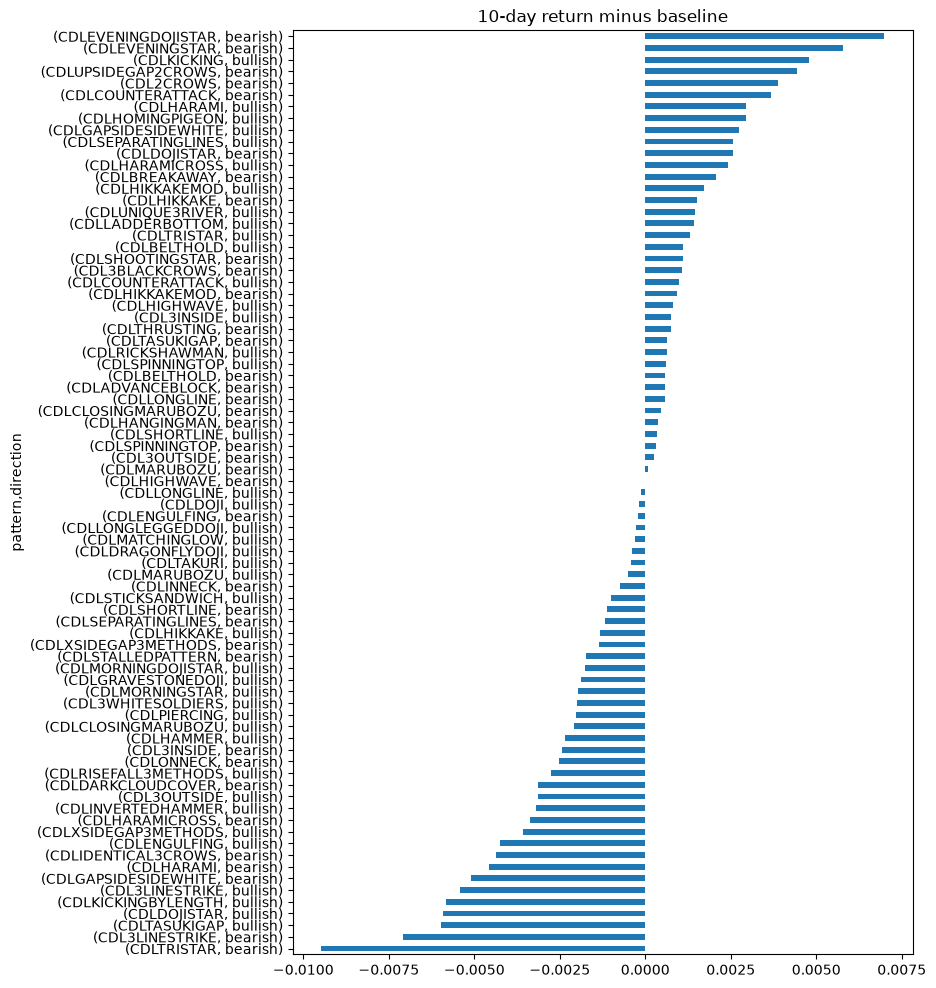

In [9]:
excess_10d = (summary['return_10d'] - baseline['return_10d']).sort_values()
excess_10d.plot.barh(figsize=(8, 12), title='10-day return minus baseline');

## 5. 把型態畫出來

挑出表現最好的型態，畫出其中一次訊號前後的 K 線。

In [10]:
def plot_candles(kbar: pd.DataFrame, title: str) -> None:
    """用 matplotlib 畫 K 線：紅 K 代表收盤高於開盤，綠 K 代表收盤低於開盤。"""
    rising = kbar['close'] >= kbar['open']
    colors = rising.map({True: 'tab:red', False: 'tab:green'})
    x = range(len(kbar))
    body_bottom = kbar[['open', 'close']].min(axis=1)
    body_height = (kbar['close'] - kbar['open']).abs()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.vlines(x, kbar['low'], kbar['high'], colors=colors, linewidth=1)
    ax.bar(x, body_height, bottom=body_bottom, color=colors, width=0.7)
    ax.set_xticks(list(x), kbar.index.strftime('%m-%d'), rotation=90)
    ax.set_title(title)
    ax.grid(alpha=0.3)

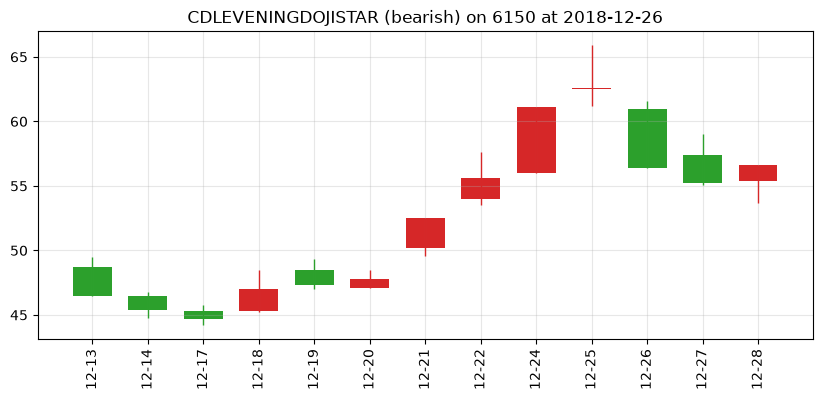

In [11]:
WINDOW_BEFORE = 10
WINDOW_AFTER = 10

prices = {field: data.get(f'price:{name}') for field, name in
          [('open', '開盤價'), ('high', '最高價'), ('low', '最低價'), ('close', '收盤價')]}

best_pattern, best_direction = summary.index[0]
example = events[(events['pattern'] == best_pattern) & (events['direction'] == best_direction)].iloc[-1]

kbar = pd.DataFrame({field: table[example['instrument']] for field, table in prices.items()}).dropna()
position = kbar.index.get_loc(example['datetime'])
kbar = kbar.iloc[max(position - WINDOW_BEFORE, 0): position + WINDOW_AFTER + 1]

plot_candles(kbar, f"{best_pattern} ({best_direction}) on {example['instrument']} at {example['datetime']:%Y-%m-%d}")

單一 K 線型態的效果通常不大，而且不同時期表現會變。下一個單元把型態寫成「進場訊號」，搭配出場條件做成全股票回測。